In [58]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 📘 Table of Contents

1. [4.1 Understanding of the Data](#41-understanding-of-the-data)
   - [4.1.3 Descriptive Statistics](#413-descriptive-statistics)

2. [4.2 Data Preprocessing](#42-data-preprocessing)
   - [4.2.1 Handling Missing Values](#421-handling-missing-values)

3. [4.3 Exploratory Data Analysis](#43-exploratory-data-analysis)
   - [4.3.1 Distribution and Correlation](#431-disribution-and-correlation)

4. [4.4 Model Development and Evaluation](#44-model-development-and-evaluation)
   - [4.4.1 Standardisation and One-Hot Encoding Variable](#441-standardisation-and-one-hot-encoding-variable)
   - [4.4.2 Training the Model](#442-training-the-model)
   - [4.4.3 Evaluating the Model](#443-evaluating-the-model)


#4.1 Understanding of the data

importing libraries

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [60]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Coursework/retail_store_sales.csv")

Exploring  dataset

In [61]:
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [62]:
df.tail()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,NaN
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,NaN
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True
12574,TXN_2407494,CUST_23,Food,Item_9_FOOD,17.0,3.0,51.0,Cash,Online,2022-08-06,NaN


##4.1.3 Descriptive statistics

In [63]:
df.shape

(12575, 11)

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


In [65]:
df.describe()


,Price Per Unit,Quantity,Total Spent
count,11966.000000,11971.000000,11971.000000
mean,23.365912,5.536380,129.652577
std,10.743519,2.857883,94.750697
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,51.000000
50%,23.000000,6.000000,108.500000
75%,33.500000,8.000000,192.000000
max,41.000000,10.000000,410.000000


# 4.2 Data Preprocessing

In [66]:
print(df.isnull().sum())
#check number of items missing in dataset

Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
Total Spent          604
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
dtype: int64


In [67]:
df.drop_duplicates()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False
...,...,...,...,...,...,...,...,...,...,...,...
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,NaN
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,NaN
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True


In [68]:
df=df.drop(columns="Transaction ID")

In [69]:
df.columns.tolist()

['Customer ID',
 'Category',
 'Item',
 'Price Per Unit',
 'Quantity',
 'Total Spent',
 'Payment Method',
 'Location',
 'Transaction Date',
 'Discount Applied']

## 4.2.1 Handling missing values

function to have a better understanding about missing data



In [70]:
def missing_Data_report(df):
  missing_data = df.isnull().sum()
  total_missing=missing_data.sum()
  total=df.shape[0] #total rows

  missing_percent=(missing_data/total)*100
  missing_percentage=(round(missing_percent,2)) #missing column values rounded to 2 decimals

  report_summary=pd.DataFrame({
      "Missing Values":missing_data,
      "missing_percentage %":missing_percentage
  })
  report_summary = report_summary[report_summary["Missing Values"] > 0]
  overall_percent=(total_missing/df.size)*100
  overall_percentage=(round(overall_percent,2)) #overall missing rounded to 2 decimal

  print("Column-wise Missing Data Report:\n")
  print( report_summary)
  print()
  print(f"Total missing values: {total_missing}")
  print(f"Overall missing percentage: {overall_percentage}%")
  return report_summary,overall_percentage

report,overall=missing_Data_report(df)







Column-wise Missing Data Report:

                  Missing Values  missing_percentage %
Item                        1213                  9.65
Price Per Unit               609                  4.84
Quantity                     604                  4.80
Total Spent                  604                  4.80
Discount Applied            4199                 33.39

Total missing values: 7229
Overall missing percentage: 5.75%


In [71]:
df['Discount Applied']= df['Discount Applied'].fillna("False")
df.head()

,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,False
4,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


Using logic of total spent / quantity to get the price per unit

In [72]:
# Only fill where Price Per Unit is missing and Quantity is not zero/NaN
mask = df['Price Per Unit'].isna() & df['Quantity'].notna() & (df['Quantity'] != 0)

df.loc[mask, 'Price Per Unit'] = df.loc[mask, 'Total Spent'] / df.loc[mask, 'Quantity']

print(f"Remaining missing Price Per Unit: {df['Price Per Unit'].isna().sum()}")



Remaining missing Price Per Unit: 0


filling some missing 'Item' based on Category + price per unit

In [73]:
df['Item'] = df['Item'].fillna(df.groupby(['Category', 'Price Per Unit'])['Item'].transform('first')
)
print(f"Remaining missing Item names: {df['Item'].isna().sum()}")


Remaining missing Item names: 0


Proceeding with a way to handle missing values for quantity and total spent

In [74]:
df.loc[df['Total Spent'].isna() & df['Quantity'].notna() & df['Price Per Unit'].notna(), 'Total Spent'] = \
    df['Quantity'] * df['Price Per Unit'] #filling where total spent is missing but quantity and price per unit is known


In [75]:
df.loc[df['Quantity'].isna() & df['Total Spent'].notna() & df['Price Per Unit'].notna(), 'Quantity'] = \
    df['Total Spent'] / df['Price Per Unit'] #filling where quantity is missing but total spent and price per unit is known

In [76]:
print(df.isnull().sum())

Customer ID           0
Category              0
Item                  0
Price Per Unit        0
Quantity            604
Total Spent         604
Payment Method        0
Location              0
Transaction Date      0
Discount Applied      0
dtype: int64


this means that the 604 data missing on both columns are in the same row

In [77]:
df['Missing_Both'] = df['Quantity'].isna() & df['Total Spent'].isna()


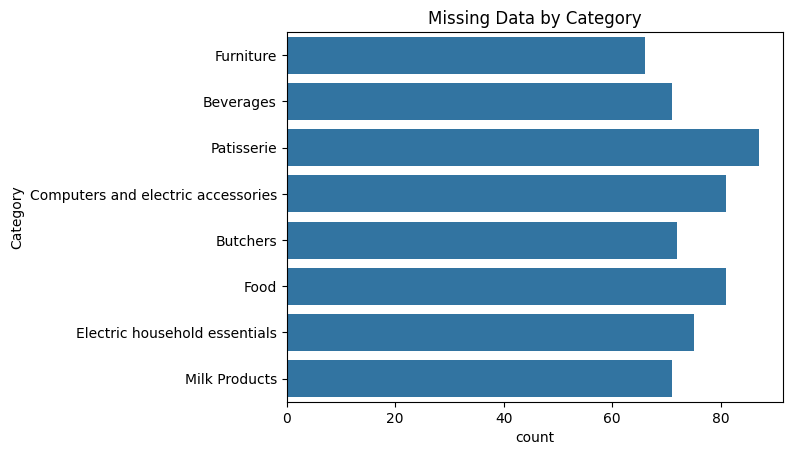

In [78]:
#graph for missing by category
sns.countplot(data=df[df['Missing_Both']], y='Category')
plt.title('Missing Data by Category')
plt.show()


Using median to impute

In [79]:
df['Quantity']=df['Quantity'].fillna(df.groupby('Item')['Quantity'].transform('median'))

In [80]:
df['Total Spent']=df['Total Spent'].fillna(df.groupby('Item')['Total Spent'].transform('median'))

number of missing data left after preprocessing

In [81]:
print(df.isnull().sum())

Customer ID         0
Category            0
Item                0
Price Per Unit      0
Quantity            0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Discount Applied    0
Missing_Both        0
dtype: int64


correcting data types

In [82]:
df['Discount Applied'] = df['Discount Applied'].astype(str)
df['Discount Applied'] = df['Discount Applied'].map({'True': True, 'False': False})
df['Location'] = df['Location'].astype('category')
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])
df['Payment Method'] = df['Payment Method'].astype('category')
df['Item'] = df['Item'].astype('category')
df['Category'] = df['Category'].astype('category')
df.drop('Missing_Both', axis=1, inplace=True)
#assiging appropriate data type to each variable


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Customer ID       12575 non-null  object        
 1   Category          12575 non-null  category      
 2   Item              12575 non-null  category      
 3   Price Per Unit    12575 non-null  float64       
 4   Quantity          12575 non-null  float64       
 5   Total Spent       12575 non-null  float64       
 6   Payment Method    12575 non-null  category      
 7   Location          12575 non-null  category      
 8   Transaction Date  12575 non-null  datetime64[ns]
 9   Discount Applied  12575 non-null  bool          
dtypes: bool(1), category(4), datetime64[ns](1), float64(3), object(1)
memory usage: 575.3+ KB


#4.3 Exploratory Data Analysis

In [83]:
df.groupby('Category')['Total Spent'].mean() #mean of total spent per category

/tmp/ipython-input-1260373891.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Category')['Total Spent'].mean() #mean of total spent per category


,Total Spent
Category,
Beverages,131.872687
Butchers,138.524554
Computers and electric accessories,129.236361
Electric household essentials,134.886235
Food,128.766845
Furniture,128.646292
Milk Products,119.373106
Patisserie,126.375327


/tmp/ipython-input-900898298.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_spending = df.groupby('Category')['Total Spent'].sum().sort_values(ascending=False) #Total spent per category
/tmp/ipython-input-900898298.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-900898298.py:4: UserWarning: 
The palette list has fewer values (6) than needed (8) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


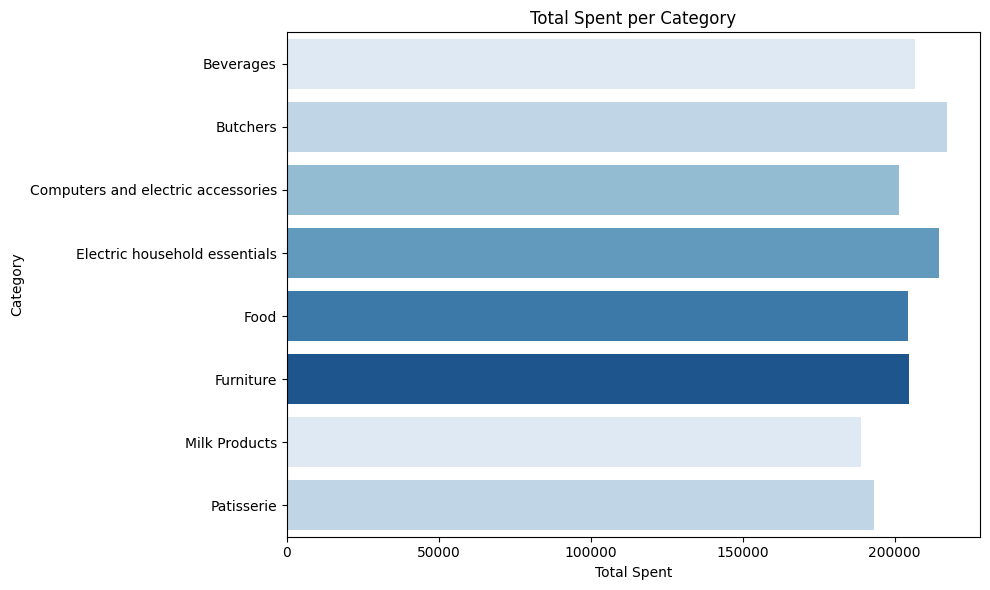

In [84]:
category_spending = df.groupby('Category')['Total Spent'].sum().sort_values(ascending=False) #Total spent per category

plt.figure(figsize=(10,6))
sns.barplot(
    x=category_spending.values,
    y=category_spending.index,
    palette=sns.color_palette("Blues"))
plt.title('Total Spent per Category')
plt.xlabel('Total Spent')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

/tmp/ipython-input-1536994421.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Location', y='Total Spent', data=df, estimator='mean', palette='Blues')


<Axes: xlabel='Location', ylabel='Total Spent'>

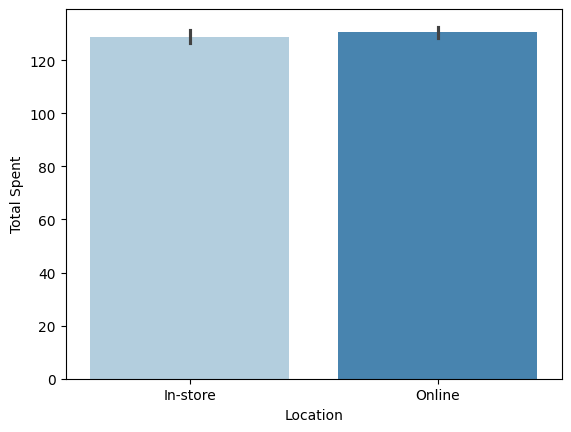

In [85]:
sns.barplot(x='Location', y='Total Spent', data=df, estimator='mean', palette='Blues')


/tmp/ipython-input-55766631.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Payment Method', y='Total Spent', data=df, palette='crest')


<Axes: xlabel='Payment Method', ylabel='Total Spent'>

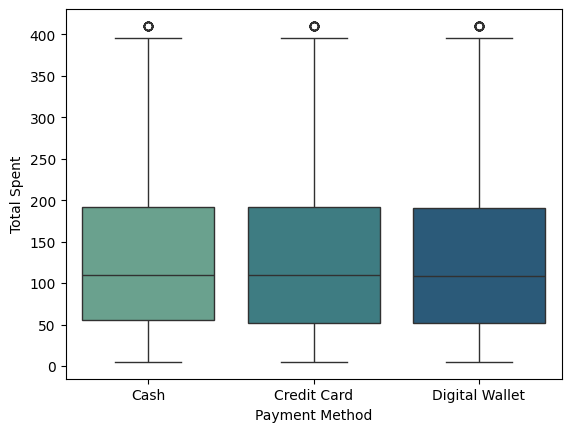

In [86]:
sns.boxplot(x='Payment Method', y='Total Spent', data=df, palette='crest')


In [87]:
df.describe(include=[np.number])


,Price Per Unit,Quantity,Total Spent
count,12575.000000,12575.000000,12575.000000
mean,23.369304,5.537535,129.713857
std,10.748728,2.792066,93.450517
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,52.000000
50%,23.000000,6.000000,109.500000
75%,33.500000,8.000000,190.000000
max,41.000000,10.000000,410.000000


##4.3.1 Disribution and Correlation

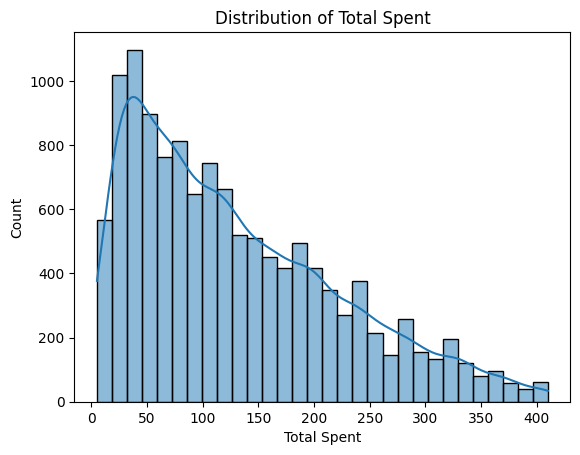

In [88]:
sns.histplot(df['Total Spent'], bins=30, kde=True)
plt.title("Distribution of Total Spent")
plt.show()

In [89]:
df['Total Spent'].skew()


np.float64(0.8245804539680178)

this shows that the distribution of total spent  is skewed to the right(few people spends a lot)

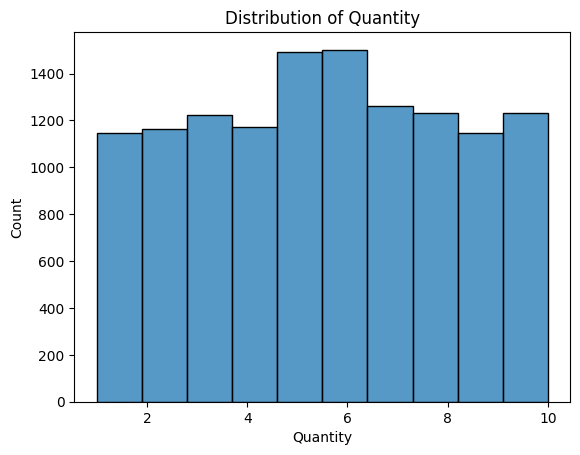

In [90]:
sns.histplot(df['Quantity'],bins=10,kde=False)
plt.title("Distribution of Quantity")
plt.show()

In [91]:
df['Quantity'].skew()

np.float64(-0.013091608300801407)

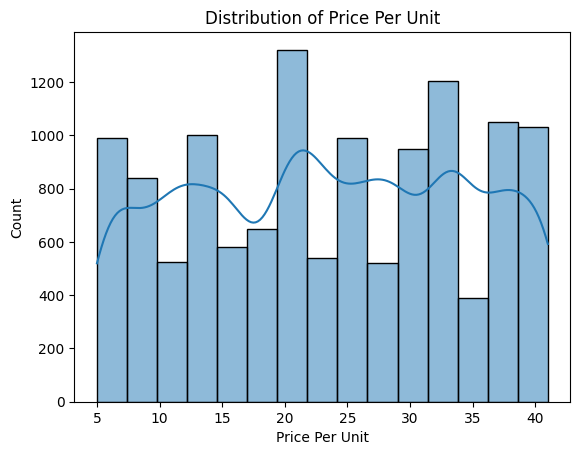

In [92]:
sns.histplot(df['Price Per Unit'], bins=15, kde=True)
plt.title("Distribution of Price Per Unit")
plt.show()

In [93]:
df['Price Per Unit'].skew()

np.float64(-0.03428323241779171)

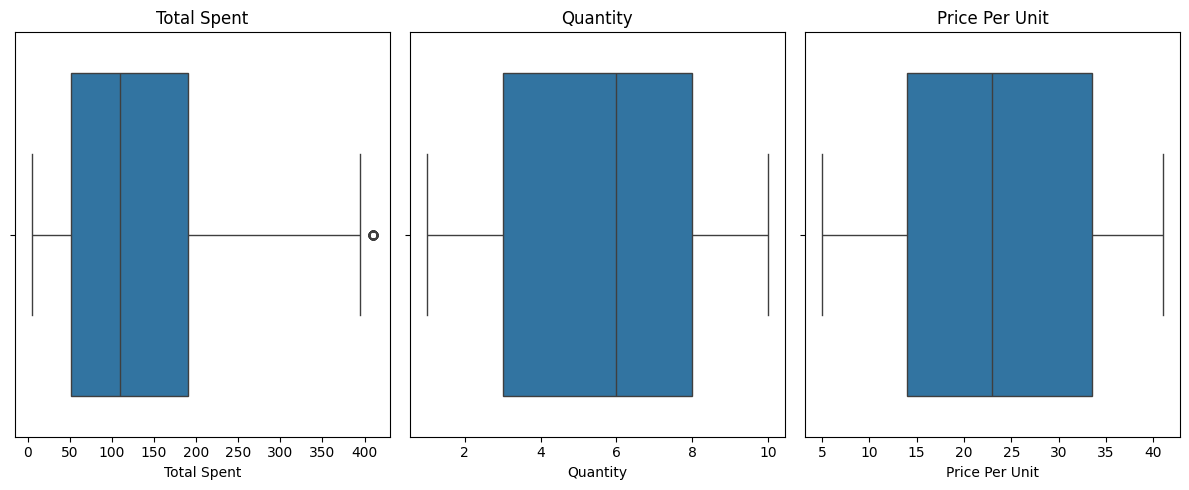

In [94]:
plt.figure(figsize=(12,5))
#1st subplot
plt.subplot(1, 3, 1)
sns.boxplot(x=df['Total Spent'])
plt.title('Total Spent')
#2nd subplot
plt.subplot(1, 3, 2)
sns.boxplot(x=df['Quantity'])
plt
plt.title('Quantity')
#3rd subplot
plt.subplot(1, 3, 3)
sns.boxplot(x=df['Price Per Unit'])
plt.title('Price Per Unit')

plt.tight_layout()
plt.show()


Outliers report

In [95]:
#outlier report for total spent
Q1=df['Total Spent'].quantile(0.25)
Q3=df['Total Spent'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outliers=df[(df['Total Spent']<lower_bound) |(df['Total Spent']>upper_bound)]
print(f"Lower Bound = {lower_bound}")
print(f"Upper Bound = {upper_bound}")
print(f"Number of outliers: {len(outliers)}")
print(f"Percentage of outliers: {len(outliers)/df.shape[0] * 100:.2f} %")

Lower Bound = -155.0
Upper Bound = 397.0
Number of outliers: 60
Percentage of outliers: 0.48 %


In [96]:
#outlier report for Price Per Unit
Q1=df['Price Per Unit'].quantile(0.25)
Q3=df['Price Per Unit'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outliers=df[(df['Price Per Unit']<lower_bound) |(df['Price Per Unit']>upper_bound)]
print(f"Lower Bound = {lower_bound}")
print(f"Upper Bound = {upper_bound}")
print(f"Number of outliers: {len(outliers)}")

Lower Bound = -15.25
Upper Bound = 62.75
Number of outliers: 0


In [97]:
#Outlier report for quantity
Q1=df['Quantity'].quantile(0.25)
Q3=df['Quantity'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outliers=df[(df['Quantity']<lower_bound) |(df['Quantity']>upper_bound)]
print(f"Lower Bound = {lower_bound}")
print(f"Upper Bound = {upper_bound}")
print(f"Number of outliers: {len(outliers)}")

Lower Bound = -4.5
Upper Bound = 15.5
Number of outliers: 0


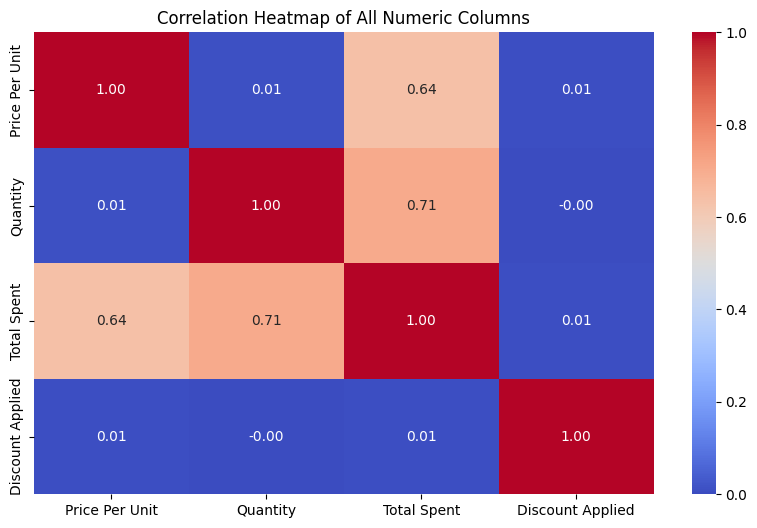

In [98]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of All Numeric Columns")
plt.show()

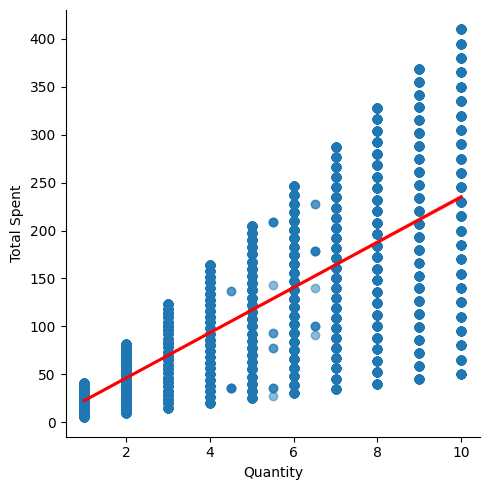

In [99]:
sns.lmplot(
    x='Quantity',
    y='Total Spent',
    data=df,
    line_kws={'color': 'red'},
    scatter_kws={'alpha': 0.5}
)



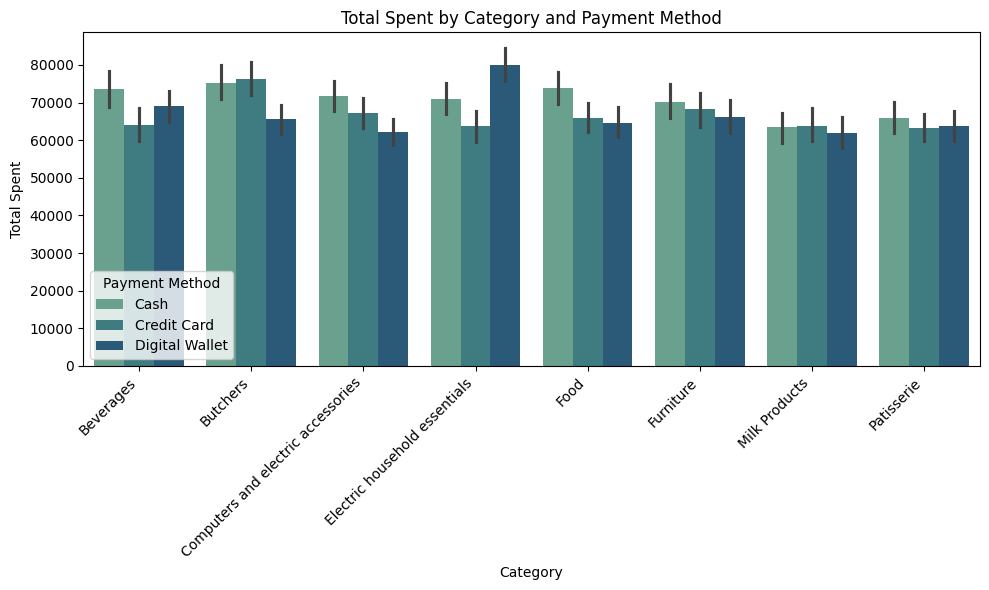

In [100]:

plt.figure(figsize=(10,6))
sns.barplot(
    x='Category',
    y='Total Spent',
    hue='Payment Method',
    data=df,
    estimator=sum,
    palette='crest'
)
plt.xticks(rotation=45, ha='right')
plt.title('Total Spent by Category and Payment Method')
plt.tight_layout()




/tmp/ipython-input-1880963721.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


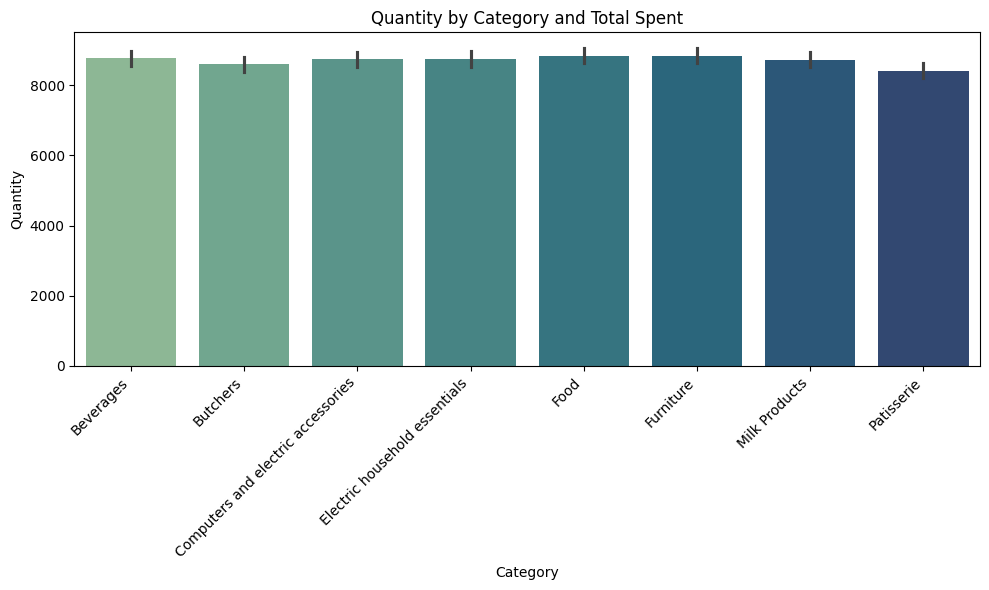

In [101]:
plt.figure(figsize=(10,6))
sns.barplot(
    x='Category',
    y='Quantity',
    data=df,
    estimator=sum,

    palette='crest'

)
plt.title("Quantity by Category and Total Spent")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1615: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=x, y=y, **kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1615: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=x, y=y, **kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1615: UserWarning: Ignoring `palette` because no `hue` variable has been as

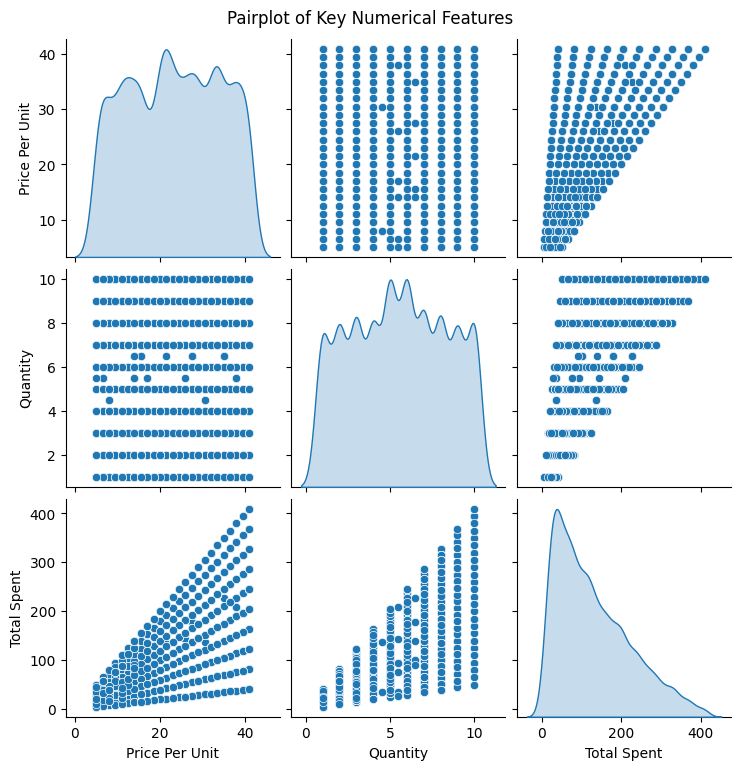

In [102]:
sns.pairplot(
    df[['Price Per Unit', 'Quantity', 'Total Spent']],
    diag_kind='kde',
    palette='crest'
)
plt.suptitle('Pairplot of Key Numerical Features', y=1.02)
plt.show()


#4.4 Model Development and Evaluation

##4.4.1 Standardisation and one-hot encoding variable

In [103]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


In [104]:
#one-hot encoding variable
df['Discount Applied'] = df['Discount Applied'].astype(int)
df=pd.get_dummies(df,columns=['Category','Payment Method','Location'], drop_first=True)


In [105]:
df.head()

,Customer ID,Item,Price Per Unit,Quantity,Total Spent,Transaction Date,Discount Applied,Category_Butchers,Category_Computers and electric accessories,Category_Electric household essentials,Category_Food,Category_Furniture,Category_Milk Products,Category_Patisserie,Payment Method_Credit Card,Payment Method_Digital Wallet,Location_Online
0,CUST_09,Item_10_PAT,18.5,10.0,185.0,2024-04-08,1,False,False,False,False,False,False,True,False,True,True
1,CUST_22,Item_17_MILK,29.0,9.0,261.0,2023-07-23,1,False,False,False,False,False,True,False,False,True,True
2,CUST_02,Item_12_BUT,21.5,2.0,43.0,2022-10-05,0,True,False,False,False,False,False,False,True,False,True
3,CUST_06,Item_16_BEV,27.5,9.0,247.5,2022-05-07,0,False,False,False,False,False,False,False,True,False,True
4,CUST_05,Item_6_FOOD,12.5,7.0,87.5,2022-10-02,0,False,False,False,True,False,False,False,False,True,True


In [106]:
x=df.drop(columns=['Total Spent','Transaction Date','Customer ID','Item'])
y=df['Total Spent']

In [107]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [108]:
#standardising numerical features
scaler=StandardScaler()
num_columns=['Price Per Unit', 'Quantity']
x_train[num_columns] = scaler.fit_transform(x_train[num_columns])
x_test[num_columns] = scaler.transform(x_test[num_columns])

In [109]:
print(x_train[num_columns].mean())
print(x_train[num_columns].std())

Price Per Unit    7.769354e-17
Quantity          6.215483e-17
dtype: float64
Price Per Unit    1.00005
Quantity          1.00005
dtype: float64


##4.4.2 Training the Model


In [110]:
from sklearn.linear_model import LinearRegression
regressor=LinearRegression()
regressor.fit(x_train,y_train) #training model

LinearRegression()

In [111]:
y_pred=regressor.predict(x_test)


##4.4.3 Evaluating the Model

In [112]:

from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
mse=mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2=r2_score(y_test,y_pred)
print("MSE:", mse)
print("MAE:", mae)
print("R² Score:", r2)


MSE: 907.5806525130865
MAE: 22.260698426968684
R² Score: 0.8984761860572317


In [113]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(rmse)

30.12607927548964


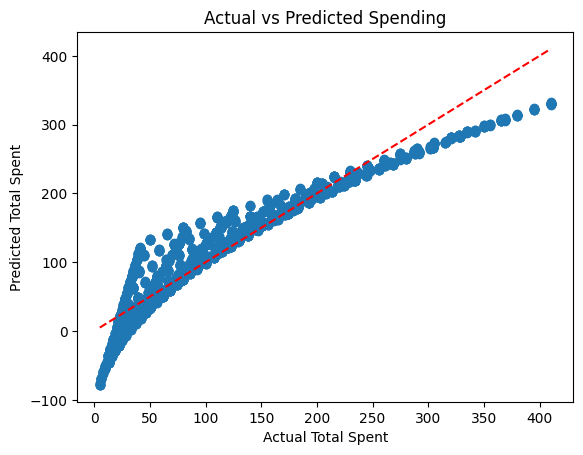

In [114]:

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Total Spent")
plt.ylabel("Predicted Total Spent")
plt.title("Actual vs Predicted Spending")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')  # diagonal reference line
plt.show()
